In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


BASE_DATE = "JUN11"
ROOT = Path("_json/_run")


def parse_run_label(experiment_id):
    run_id = experiment_id.split("__", 1)[1]

    if run_id.startswith("ETHlib_3R2C_"):
        lib = "ETHlib_3R2C"
        model_complexity = "3R2C"
        data_source = run_id.replace("ETHlib_3R2C_", "")

    elif run_id.startswith("ETHlib_"):
        lib = "ETHlib"
        model_complexity = "5R1C"
        data_source = run_id.replace("ETHlib_", "")

    else:
        raise ValueError(f"Cannot parse run label: {experiment_id}")

    data_label = {
        "default_occ": "Default occupancy",
        "ONSITE_occ": "On-site occupancy",
        "bldg_LoD_Y": "LoD-Y occupancy",
    }.get(data_source, data_source)

    return lib, model_complexity, data_source, data_label


def collect_outcomes(base_date="JUN11"):
    metric_tables = []
    saving_tables = []

    for run_dir in sorted(ROOT.glob(f"{base_date}__*")):
        experiment_id = run_dir.name
        outcome_dir = run_dir / "_outcome" / experiment_id

        metric_path = outcome_dir / "baseline_metrics_daily.csv"
        saving_path = outcome_dir / "ecm_savings_daily.csv"

        if not metric_path.exists():
            print(f"[WARN] Missing: {metric_path}")
            continue

        if not saving_path.exists():
            print(f"[WARN] Missing: {saving_path}")
            continue

        lib, model_complexity, data_source, data_label = parse_run_label(
            experiment_id
        )

        metric_df = pd.read_csv(metric_path)
        saving_df = pd.read_csv(saving_path)

        for df in [metric_df, saving_df]:
            df["run_label"] = experiment_id
            df["lib"] = lib
            df["model_complexity"] = model_complexity
            df["data_source"] = data_source
            df["data_label"] = data_label

        metric_tables.append(metric_df)
        saving_tables.append(saving_df)

    metrics_all = pd.concat(metric_tables, ignore_index=True)
    savings_all = pd.concat(saving_tables, ignore_index=True)

    data_order = [
        "Default occupancy",
        "On-site occupancy",
        "LoD-Y occupancy",
    ]

    model_order = [
        "3R2C",
        "5R1C",
    ]

    metrics_all["data_label"] = pd.Categorical(
        metrics_all["data_label"],
        categories=data_order,
        ordered=True,
    )

    savings_all["data_label"] = pd.Categorical(
        savings_all["data_label"],
        categories=data_order,
        ordered=True,
    )

    metrics_all["model_complexity"] = pd.Categorical(
        metrics_all["model_complexity"],
        categories=model_order,
        ordered=True,
    )

    savings_all["model_complexity"] = pd.Categorical(
        savings_all["model_complexity"],
        categories=model_order,
        ordered=True,
    )

    return metrics_all, savings_all


metrics_all, savings_all = collect_outcomes(BASE_DATE)

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/172689144.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


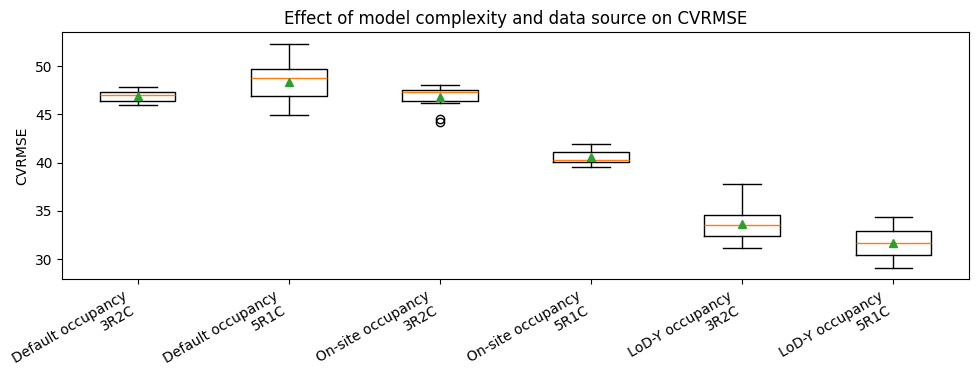

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/172689144.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


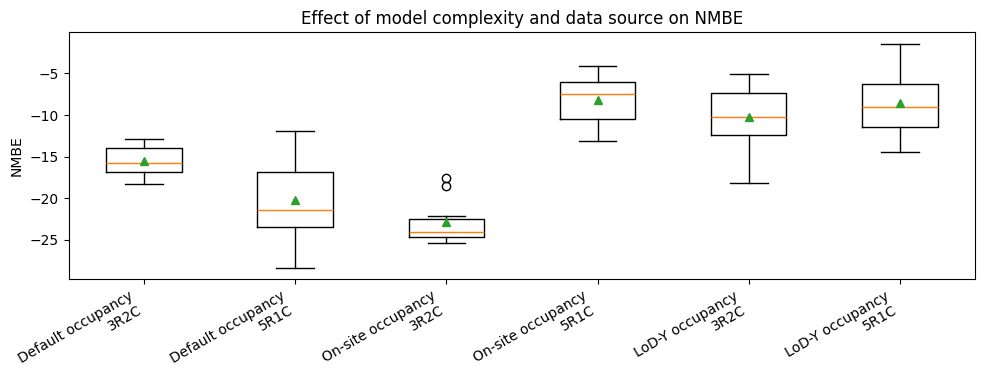

In [2]:
def plot_calibration_metric(metrics_all, metric="cvrmse"):
    plot_df = metrics_all.copy()

    groups = []
    labels = []

    for data_label in plot_df["data_label"].cat.categories:
        for model_complexity in plot_df["model_complexity"].cat.categories:
            sub = plot_df[
                (plot_df["data_label"] == data_label)
                & (plot_df["model_complexity"] == model_complexity)
            ]

            if len(sub) == 0:
                continue

            groups.append(sub[metric].dropna())
            labels.append(f"{data_label}\n{model_complexity}")

    plt.figure(figsize=(10, 4))
    plt.boxplot(groups, labels=labels, showmeans=True)
    plt.ylabel(metric.upper())
    plt.xticks(rotation=30, ha="right")
    plt.title(f"Effect of model complexity and data source on {metric.upper()}")
    plt.tight_layout()
    plt.show()


plot_calibration_metric(metrics_all, metric="cvrmse")
plot_calibration_metric(metrics_all, metric="nmbe")

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


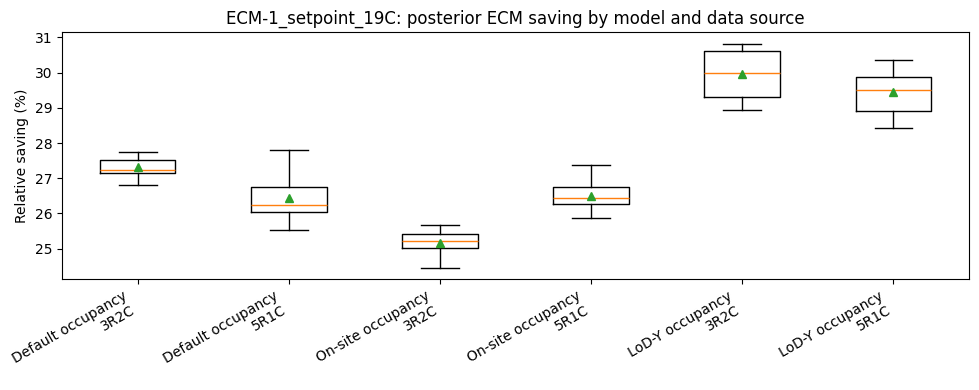

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


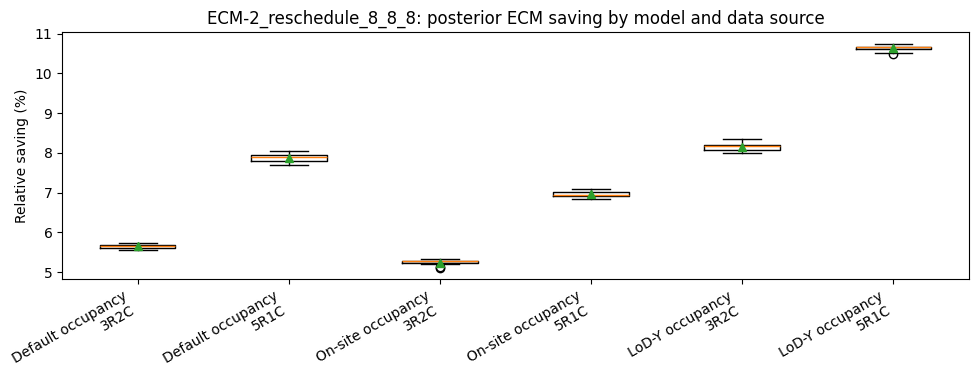

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


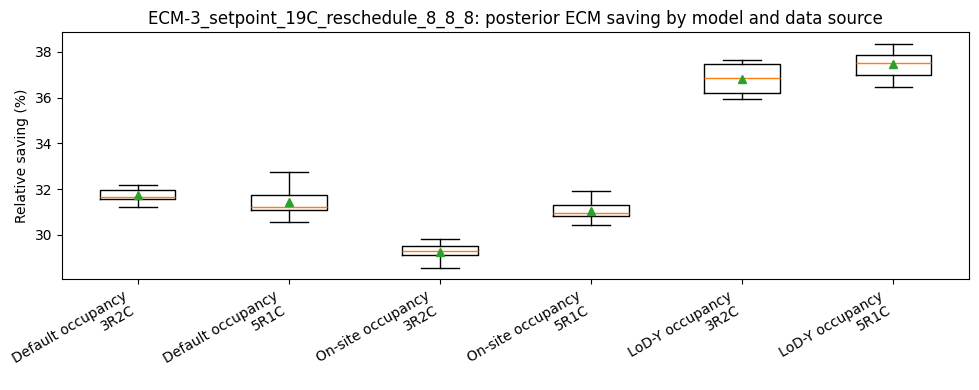

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


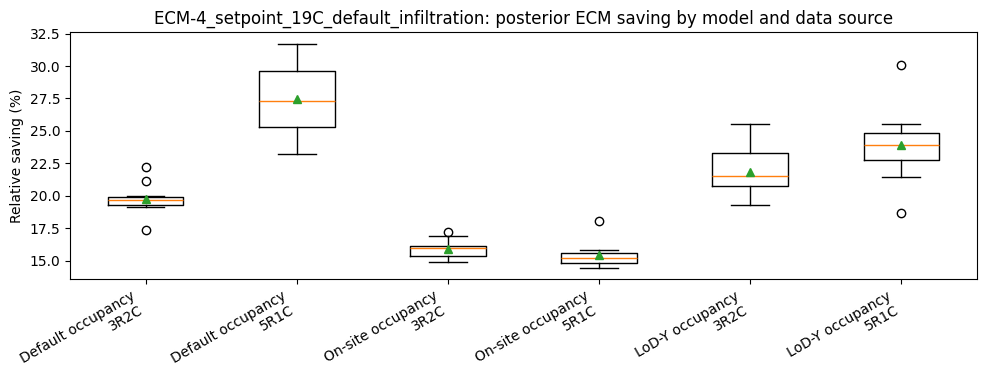

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


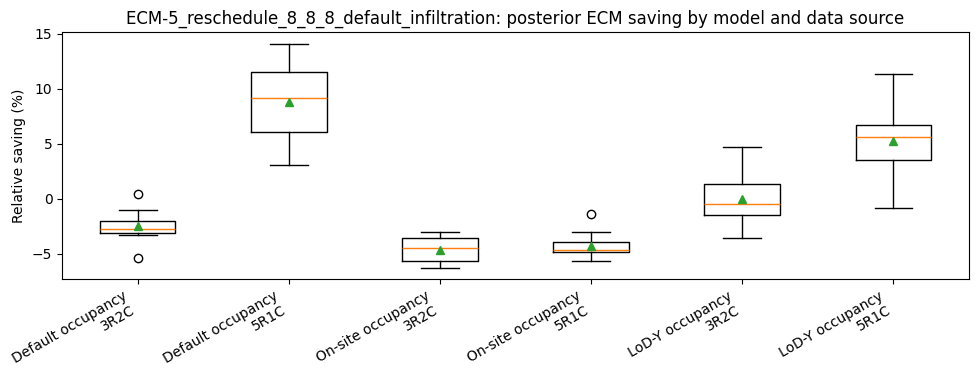

In [3]:
def plot_ecm_savings_by_group(
    savings_all,
    ecm,
    saving_col="saving_rel",
):
    plot_df = savings_all[savings_all["ecm"] == ecm].copy()

    groups = []
    labels = []

    for data_label in plot_df["data_label"].cat.categories:
        for model_complexity in plot_df["model_complexity"].cat.categories:
            sub = plot_df[
                (plot_df["data_label"] == data_label)
                & (plot_df["model_complexity"] == model_complexity)
            ]

            if len(sub) == 0:
                continue

            groups.append(sub[saving_col].dropna())
            labels.append(f"{data_label}\n{model_complexity}")

    plt.figure(figsize=(10, 4))
    plt.boxplot(groups, labels=labels, showmeans=True)

    if saving_col == "saving_rel":
        plt.ylabel("Relative saving (%)")
    else:
        plt.ylabel("Absolute saving")

    plt.xticks(rotation=30, ha="right")
    plt.title(f"{ecm}: posterior ECM saving by model and data source")
    plt.tight_layout()
    plt.show()


for ecm in savings_all["ecm"].unique():
    plot_ecm_savings_by_group(
        savings_all=savings_all,
        ecm=ecm,
        saving_col="saving_rel",
    )

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


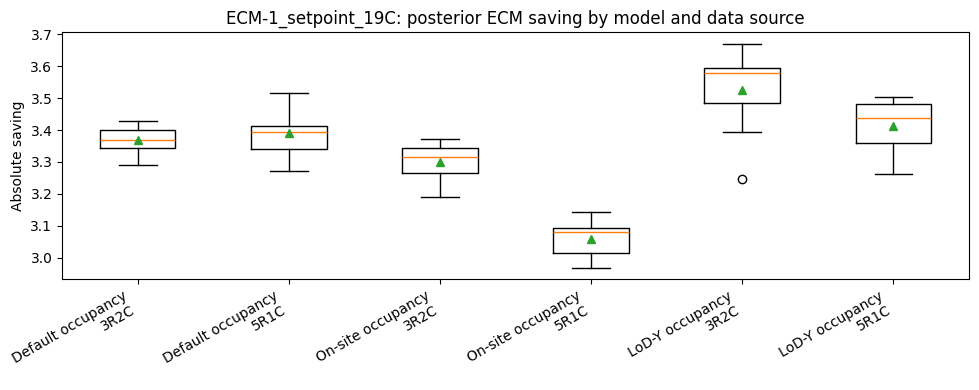

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


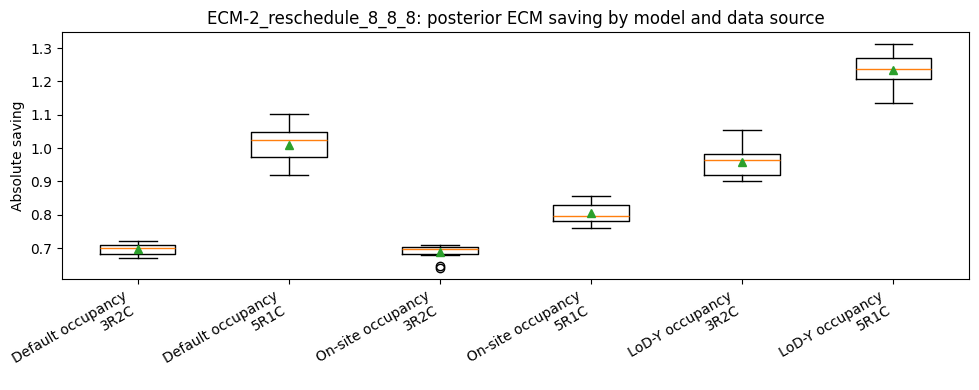

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


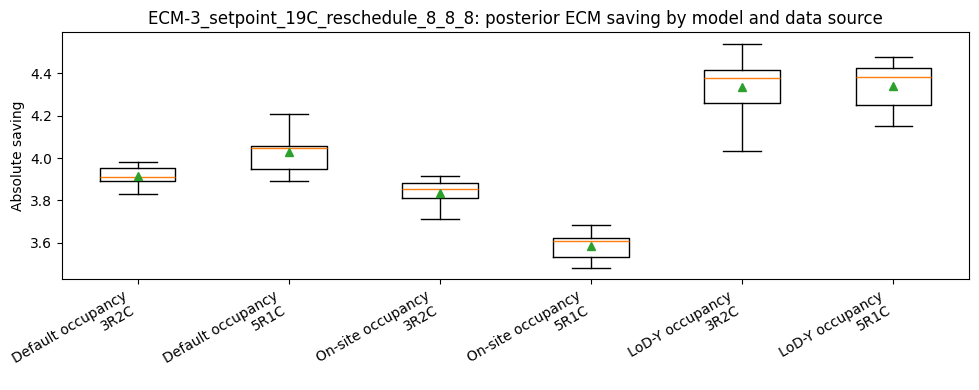

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


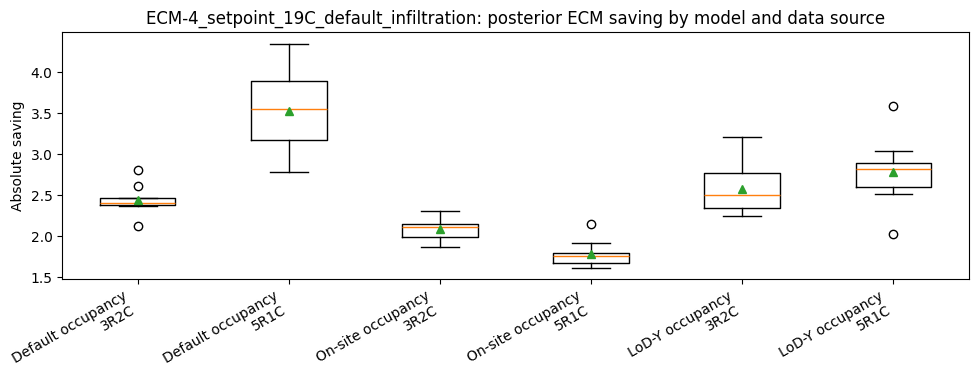

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_79309/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


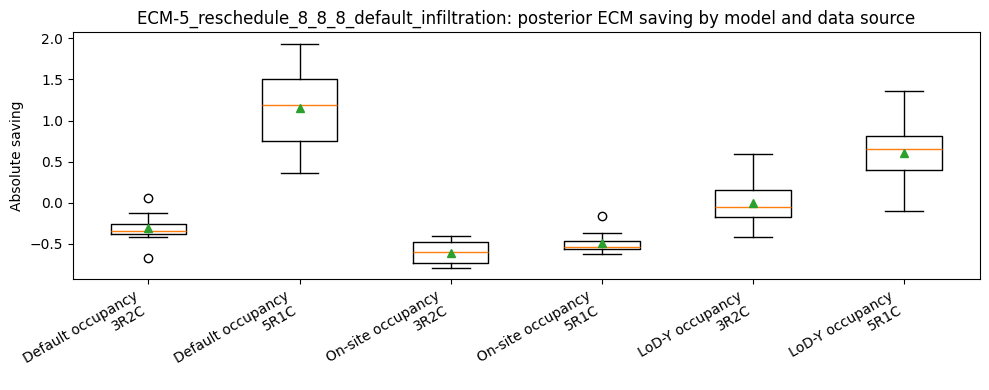

In [4]:
for ecm in savings_all["ecm"].unique():
    plot_ecm_savings_by_group(
        savings_all=savings_all,
        ecm=ecm,
        saving_col="saving_abs",
    )

In [5]:
calibration_summary = (
    metrics_all
    .groupby(["data_label", "model_complexity"], observed=True)
    .agg(
        n_samples=("sample_id", "nunique"),
        cvrmse_mean=("cvrmse", "mean"),
        cvrmse_median=("cvrmse", "median"),
        cvrmse_std=("cvrmse", "std"),
        nmbe_mean=("nmbe", "mean"),
        nmbe_median=("nmbe", "median"),
        nmbe_std=("nmbe", "std"),
    )
    .reset_index()
)

ecm_summary = (
    savings_all
    .groupby(["ecm", "data_label", "model_complexity"], observed=True)
    .agg(
        n_samples=("sample_id", "nunique"),
        saving_abs_mean=("saving_abs", "mean"),
        saving_abs_median=("saving_abs", "median"),
        saving_abs_std=("saving_abs", "std"),
        saving_rel_mean=("saving_rel", "mean"),
        saving_rel_median=("saving_rel", "median"),
        saving_rel_std=("saving_rel", "std"),
        saving_rel_q05=("saving_rel", lambda x: x.quantile(0.05)),
        saving_rel_q95=("saving_rel", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

calibration_summary, ecm_summary

(          data_label model_complexity  n_samples  cvrmse_mean  cvrmse_median  \
 0  Default occupancy             3R2C         10    46.899013      46.966199   
 1  Default occupancy             5R1C         10    48.383331      48.810092   
 2  On-site occupancy             3R2C         10    46.759721      47.279574   
 3  On-site occupancy             5R1C         10    40.538833      40.302229   
 4    LoD-Y occupancy             3R2C         10    33.668331      33.502605   
 5    LoD-Y occupancy             5R1C         10    31.650360      31.714289   
 
    cvrmse_std  nmbe_mean  nmbe_median  nmbe_std  
 0    0.638147 -15.572056   -15.800410  1.798787  
 1    2.306863 -20.167530   -21.463117  5.192177  
 2    1.359113 -22.910925   -24.022182  2.739835  
 3    0.732481  -8.146096    -7.449420  2.992635  
 4    1.909017 -10.235393   -10.209448  3.923921  
 5    1.718325  -8.528134    -8.999038  4.176302  ,
                                             ecm         data_label  \
 0